# Low-Rank Adaptation of Large Language Models

LoRA is an efficient fine-tuning technique that aims to reduce the computational cost and time. It offers a more efficient alternative to computing the weigh updates (delta_W) during fine-tuning, by learning an approximation delta_W = A@B.

Due to the distributive property of matrix multiplication, we separate the pretrained weights from the updated weights that are learned during fine-tuning, and update the A and B matrixes which have less learnable parameters. The dimension of A is (in_dim, r), and the dimension of B is (r, out_dim). R is the rank or inner dimension, an hyperparameter. In the original paper, the forward pass is calculated as (alpha/r)*(x@A@B), alpha is a scaling hyperparameter. 

Source: https://arxiv.org/abs/2106.09685
Implementation inspiration: https://github.com/rasbt/LLMs-from-scratch/blob/main/appendix-E/01_main-chapter-code/appendix-E.ipynb

In [1]:
import accelerate
print(accelerate.__version__)

1.13.0


In [2]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:
import torch
import torch.nn as nn

if torch.cuda.is_available():
    device = torch.device("cuda")

print("Device:", device)
print(f"GPU: {torch.cuda.get_device_name(0)}")

model.to(device) 

Device: cuda
GPU: NVIDIA GeForce RTX 5070


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [4]:
from datasets import load_dataset
dataset = load_dataset("glue", "sst2")

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

In [6]:
dataset["train"]["sentence"][0]

'hide new secretions from the parental units '

In [7]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize(batch):
    return tokenizer(batch["sentence"], truncation=True, max_length=128, padding="max_length")

tokenized_dataset = dataset.map(tokenize, batched=True)

Parameter 'function'=<function tokenize at 0x78e4523547c0> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only shown once. Subsequent hashing failures won't be shown.


Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [8]:
tokenized_dataset["train"]["input_ids"][0][:20]

[0,
 37265,
 92,
 3556,
 2485,
 31,
 5,
 20536,
 2833,
 1437,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

In [9]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 16

torch.manual_seed(123)
tokenized_torch = tokenized_dataset.with_format("torch")
train_loader = DataLoader(
    tokenized_torch["train"],
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=True,
    drop_last=True
)
val_loader = DataLoader(
    tokenized_torch["validation"],
    batch_size=batch_size,
        num_workers=num_workers,
    shuffle=False,
    drop_last=True
)
test_loader = DataLoader(
    tokenized_torch["test"],
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    drop_last=True
)

In [10]:
print("Train loader:")
for batch in train_loader:
    input_batch = batch["input_ids"]
    target_batch = batch["label"]

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([16, 128])
Label batch dimensions torch.Size([16])


In [11]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

4209 training batches
54 validation batches
113 test batches


In [12]:
def calc_loss_batch(input_batch, target_batch, model, device, attention_mask=None):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    if attention_mask is not None:
        attention_mask = attention_mask.to(device)
    logits = model(input_batch, attention_mask).logits
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [13]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, batch in enumerate(data_loader):
        input_batch = batch["input_ids"]
        target_batch = batch["label"]
        attention_mask = batch["attention_mask"]
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device, attention_mask)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [14]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [15]:
@torch.no_grad()
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, batch in enumerate(data_loader):
        input_batch = batch["input_ids"]
        target_batch = batch["label"]
        attention_mask = batch["attention_mask"]

        if i<num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)
            attention_mask = attention_mask.to(device)
            logits = model(input_batch, attention_mask).logits
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break    
    return correct_predictions/num_examples

In [16]:
def train_classifier(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for batch in train_loader:
            input_batch = batch["input_ids"].to(device)
            target_batch = batch["label"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            optimizer.zero_grad()
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                logits = model(input_batch, attention_mask).logits
                loss = torch.nn.functional.cross_entropy(logits, target_batch)
            loss.backward()
            optimizer.step()
            
            examples_seen += input_batch.shape[0]
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Valdation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [17]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier(
    model, train_loader, val_loader, optimizer, device, num_epochs=num_epochs,
    eval_freq=200, eval_iter=5)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 0.707, Val loss 0.695
Ep 1 (Step 000200): Train loss 0.385, Val loss 0.302
Ep 1 (Step 000400): Train loss 0.271, Val loss 0.133
Ep 1 (Step 000600): Train loss 0.275, Val loss 0.113
Ep 1 (Step 000800): Train loss 0.311, Val loss 0.088
Ep 1 (Step 001000): Train loss 0.136, Val loss 0.078
Ep 1 (Step 001200): Train loss 0.184, Val loss 0.051
Ep 1 (Step 001400): Train loss 0.213, Val loss 0.096
Ep 1 (Step 001600): Train loss 0.147, Val loss 0.094
Ep 1 (Step 001800): Train loss 0.152, Val loss 0.033
Ep 1 (Step 002000): Train loss 0.086, Val loss 0.079
Ep 1 (Step 002200): Train loss 0.102, Val loss 0.090
Ep 1 (Step 002400): Train loss 0.176, Val loss 0.070
Ep 1 (Step 002600): Train loss 0.120, Val loss 0.061
Ep 1 (Step 002800): Train loss 0.140, Val loss 0.073
Ep 1 (Step 003000): Train loss 0.053, Val loss 0.100
Ep 1 (Step 003200): Train loss 0.189, Val loss 0.081
Ep 1 (Step 003400): Train loss 0.114, Val loss 0.057
Ep 1 (Step 003600): Train loss 0.109, Val loss

In [18]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(10, 4))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.show()

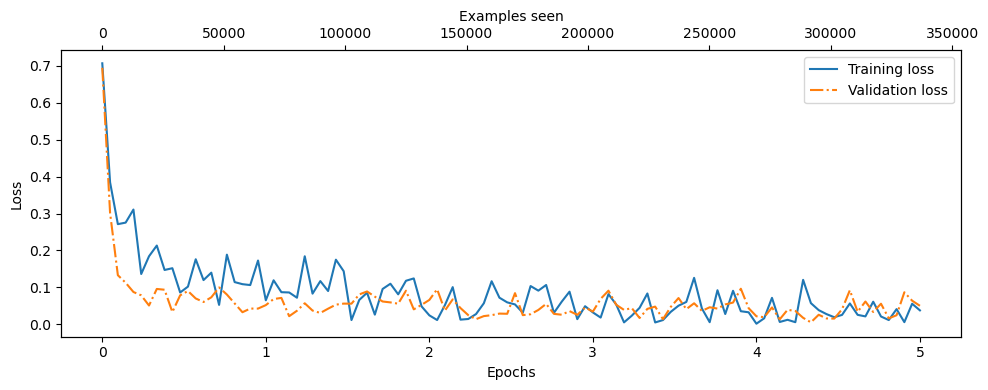

In [19]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses, label="loss")

In [20]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 98.75%
Validation accuracy: 92.71%
Test accuracy: 0.00%


In [21]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters before: {total_params:,}")

Total trainable parameters before: 124,647,170


## LoRA

Replace Q and K matrixes with LoRA matrixes with rank 8 and alpha 8

In [22]:
model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
import math

class LoraLayer(torch.nn.Module):
    def __init__(self, in_dim, out_dim, r, alpha):
        super().__init__()
        self.r = r
        self.alpha = alpha
        self.A = torch.nn.Parameter(torch.empty(in_dim, r))
        torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        self.B = torch.nn.Parameter(torch.zeros(r, out_dim))

    def forward(self, x):
        return (self.alpha / self.r) * (x @ self.A @ self.B)

In [24]:
class LoraLinear(torch.nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        self.lora = LoraLayer(linear.in_features, linear.out_features, rank, alpha)

    def forward(self, x):
        return self.linear(x) + self.lora(x)

In [25]:
def replace_qv_with_lora(model, rank, alpha):
    for param in model.parameters():
        param.requires_grad = False

    for param in model.classifier.parameters():
        param.requires_grad = True

    for layer in model.roberta.encoder.layer:
        attention = layer.attention.self
        attention.query = LoraLinear(attention.query, rank=rank, alpha=alpha)
        attention.value = LoraLinear(attention.value, rank=rank, alpha=alpha)

    return model

In [26]:
rank = 8
alpha = 8
model = replace_qv_with_lora(model, rank=rank, alpha=alpha)
model.to(device)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): LoraLinear(
                (linear): Linear(in_features=768, out_features=768, bias=True)
                (lora): LoraLayer()
              )
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): LoraLinear(
                (linear): Linear(in_features=768, out_features=768, bias=True)
                (lora): LoraLayer()
              )
              (

In [27]:
model

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): LoraLinear(
                (linear): Linear(in_features=768, out_features=768, bias=True)
                (lora): LoraLayer()
              )
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): LoraLinear(
                (linear): Linear(in_features=768, out_features=768, bias=True)
                (lora): LoraLayer()
              )
              (

In [28]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters before: {total_params:,}")

Total trainable parameters before: 887,042


The original Roberta model had 124M parameters, our new model after replacing the Q and V matrixes with the Lora matrixes has 887K parameters. It's just 0.71% of the original trainable parameters.

In [29]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier(
    model, train_loader, val_loader, optimizer, device, num_epochs=num_epochs,
    eval_freq=200, eval_iter=5)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 0.694, Val loss 0.693
Ep 1 (Step 000200): Train loss 0.674, Val loss 0.691
Ep 1 (Step 000400): Train loss 0.329, Val loss 0.225
Ep 1 (Step 000600): Train loss 0.259, Val loss 0.168
Ep 1 (Step 000800): Train loss 0.348, Val loss 0.179
Ep 1 (Step 001000): Train loss 0.165, Val loss 0.135
Ep 1 (Step 001200): Train loss 0.342, Val loss 0.123
Ep 1 (Step 001400): Train loss 0.259, Val loss 0.161
Ep 1 (Step 001600): Train loss 0.289, Val loss 0.104
Ep 1 (Step 001800): Train loss 0.191, Val loss 0.136
Ep 1 (Step 002000): Train loss 0.134, Val loss 0.108
Ep 1 (Step 002200): Train loss 0.347, Val loss 0.144
Ep 1 (Step 002400): Train loss 0.195, Val loss 0.105
Ep 1 (Step 002600): Train loss 0.211, Val loss 0.095
Ep 1 (Step 002800): Train loss 0.216, Val loss 0.095
Ep 1 (Step 003000): Train loss 0.157, Val loss 0.100
Ep 1 (Step 003200): Train loss 0.316, Val loss 0.095
Ep 1 (Step 003400): Train loss 0.260, Val loss 0.087
Ep 1 (Step 003600): Train loss 0.220, Val loss

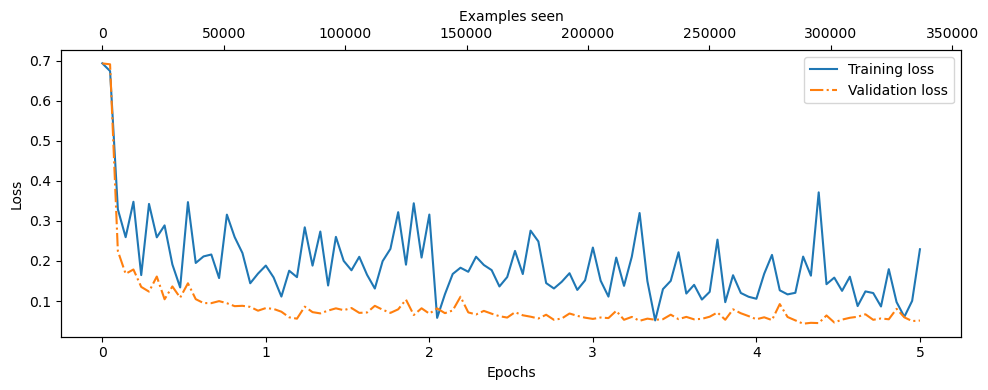

In [30]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses, label="loss")

In [31]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")

Training accuracy: 93.97%
Validation accuracy: 92.82%


As we can see the model was trained a less time, almost 9 minutes compared to the original 18 minutes for full fine-tuning, while still achieving a superior validation accuracy. We could have expected the training time to be much shorter, but that is a misconception. The loop still needs to go through the 124M Roberta parameters, and the Lora layer is adding 2 extra matmuls on top. The main benefit of LoRA is the savings on VRAM utilization, which would have been more clear if fine-tunning a larger model like LLaMA.